## Exercise 6 Markov chains
### Part 1

In [20]:
# task 1 The number of busy lines in a trunk group (Erlang system) is
#given by a truncated Poisson distribution 
# P(i) = c A^i/i!    , i=0,...,m

# generate values form this dsitribution by appluing the metropolis-Hastings 
#algorithm, verify with a X^2 -test. You can use the aprameter values form 
# exercise 4 
import numpy as np
import math
import scipy.stats as stats
np.random.seed(42)

N_CUSTUMERS = 10_000
burn_in = 100
M_SERVERS = 10
MU_SERVICE_TIME = 8
MU_ARRIVAL_TIME = 1
lam = 1
N_REPS = 10

A = MU_SERVICE_TIME / MU_ARRIVAL_TIME


def target(i, A):
    return A**i / math.factorial(i)

def q_prob(x, y, m):
    if x == 0:
        return 0.5 if y == 0 else 0.5 if y == 1 else 0
    elif x == m:
        return 0.5 if y == m else 0.5 if y == m-1 else 0
    else:
        return 0.5 if abs(y-x) == 1 else 0
    

weights = np.array([target(i, A) for i in range(M_SERVERS + 1)])
probs = weights / np.sum(weights)
for i,p in enumerate(probs):
    print(i,p)
def metropolis_hastings(A, m_servers, N, start=0):
    samples = np.zeros(N, dtype=int)
    current = start

    for t in range(N):
        # propose moving -1 or +1
        proposal = current + np.random.choice([-1, 1])

        # reject immediately if outside allowed range

        if proposal < 0 or proposal > m_servers:
            samples[t] = current
            continue

        # acceptance probability
        alpha = min(
            1,
            (target(proposal, A) * q_prob(proposal, current, m_servers)) /
            (target(current, A) * q_prob(current, proposal, m_servers))
        )

        if np.random.rand() < alpha:
            current = proposal

        samples[t] = current

    return samples

0 0.00041116370815887153
1 0.0032893096652709722
2 0.013157238661083889
3 0.03508596976289037
4 0.07017193952578074
5 0.11227510324124919
6 0.14970013765499893
7 0.17108587160571304
8 0.17108587160571304
9 0.1520763303161894
10 0.12166106425295149


In [39]:
np.random.seed(42)

samples = metropolis_hastings(A, M_SERVERS, N_CUSTUMERS, start=0)
steady_state_samples = samples[burn_in::10]

observed_counts = np.bincount(steady_state_samples, minlength=M_SERVERS+1)
observed_probs = observed_counts / len(steady_state_samples)
expected_counts = len(steady_state_samples) * probs

print("Observed probabilities:")
for i, p in enumerate(observed_probs):
    print(f"P_hat({i}) = {p:.4f}")


# mean, lower, upper = compute_ci(steady_state_samples)
# print(f"mean: {np.round(mean,4)}, Confidence 95%: [{np.round(lower,4)}, {np.round(upper,4)}] ")

expected_counts = len(steady_state_samples) * probs

chi2_stat, p_value = stats.chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print(f"Observed counts: {observed_counts}")
print(f"Expectetd: {np.round(expected_counts,1)}")

if p_value < 0.05:
    print("Reject H0: samples do not fit the target distribution.")
else:
    print("Do not reject H0: samples fit the target distribution.")

Observed probabilities:
P_hat(0) = 0.0000
P_hat(1) = 0.0051
P_hat(2) = 0.0121
P_hat(3) = 0.0343
P_hat(4) = 0.0657
P_hat(5) = 0.1212
P_hat(6) = 0.1374
P_hat(7) = 0.1879
P_hat(8) = 0.1636
P_hat(9) = 0.1525
P_hat(10) = 0.1202
Chi-square statistic: 5.405251373076491
p-value: 0.8625168724860388
Observed counts: [  0   5  12  34  65 120 136 186 162 151 119]
Expectetd: [  0.4   3.3  13.   34.7  69.5 111.2 148.2 169.4 169.4 150.6 120.4]
Do not reject H0: samples fit the target distribution.


_____
## part 2

In [10]:
# part 2 For the two different call types the joint number of the occupied lines is given by 
# # P(i,j) = c A^i_1/i! * A^j_2 /j!  , o≤i+j ≤m 

# 2 (a)
m = M_SERVERS
A1 = 4
A2 = 4
def target(state, A1, A2):
    i, j = state
    if i < 0 or j < 0 or i + j > m:
        return 0
    return (A1**i / math.factorial(i)) * (A2**j / math.factorial(j))


states = []
weights = []

for i in range(m + 1):
    for j in range(m + 1):
        if i + j <= m:
            states.append((i, j))
            weights.append(target((i, j), A1, A2))

weights = np.array(weights)
probs = weights / weights.sum()


def metropolis_hastings_direct(A1, A2, m, N, start=(0,0)):
    samples = np.zeros((N, 2), dtype=int)
    current = start

    for t in range(N):
        proposal = states[np.random.randint(len(states))]

        alpha = min(1, target(proposal, A1, A2) / target(current, A1, A2))

        if np.random.rand() < alpha:
            current = proposal

        samples[t] = current

    return samples


samples = metropolis_hastings_direct(A1, A2, m, N_CUSTUMERS, start=(0,0))
steady = samples[1000::5]

observed_counts = np.array([
    np.sum((steady[:,0] == i) & (steady[:,1] == j))
    for i, j in states
])

expected_counts = len(steady) * probs

mask = expected_counts >= 5
obs_test = np.append(observed_counts[mask], observed_counts[~mask].sum())
exp_test = np.append(expected_counts[mask], expected_counts[~mask].sum())

chi2_stat, p_value = stats.chisquare(obs_test, exp_test)

print(chi2_stat, p_value)

print(len(states))     
print(observed_counts.sum(), expected_counts.sum())

63.699963984288324 0.07724322916340381
66
1800 1799.9999999999998


_____

In [14]:

np.random.seed(42)
A1, A2 = 4, 4
m = M_SERVERS
thin = 10
burn_in = 1000

# (b) Use metropolis- Hastings coordinate wise

def target(state, A1, A2):
    i, j = state
    return (A1**i / math.factorial(i)) * (A2**j / math.factorial(j))

def q_prob(x, y, m):
    if x == 0:
        return 0.5 if y == 0 else 0.5 if y == 1 else 0
    elif x == m:
        return 0.5 if y == m else 0.5 if y == m-1 else 0
    else:
        return 0.5 if abs(y-x) == 1 else 0
    




def valid_neighbors(state, m):
    i, j = state
    possible = [(i+1,j), (i-1,j), (i,j+1), (i,j-1)]

    return [
        (a,b) for a,b in possible
        if a >= 0 and b >= 0 and a + b <= m
    ]


def metropolis_hastings_coordinate(A1, A2, m, N, start=(0,0)):
    samples = np.zeros((N, 2), dtype=int)
    current = start

    for t in range(N):
        current_neighbors = valid_neighbors(current, m)
        proposal = current_neighbors[np.random.randint(len(current_neighbors))]

        proposal_neighbors = valid_neighbors(proposal, m)

        q_forward = 1 / len(current_neighbors)
        q_backward = 1 / len(proposal_neighbors)

        alpha = min(
            1,
            (target(proposal, A1, A2) * q_backward) /
            (target(current, A1, A2) * q_forward)
        )

        if np.random.rand() < alpha:
            current = proposal

        samples[t] = current

    return samples


np.random.seed(42)

samples = metropolis_hastings_coordinate(A1, A2, M_SERVERS, N_CUSTUMERS, start=(0,0))
steady_state_samples = samples[burn_in::thin]

states = []
weights = []

for i in range(m + 1):
    for j in range(m + 1):
        if i + j <= m:
            states.append((i, j))
            weights.append(target((i, j), A1, A2))

weights = np.array(weights)
probs = weights / weights.sum()


observed_counts = []

for state in states:
    i, j = state
    count = np.sum(
        (steady_state_samples[:, 0] == i) &
        (steady_state_samples[:, 1] == j)
    )
    observed_counts.append(count)

observed_counts = np.array(observed_counts)
observed_probs = observed_counts / len(steady_state_samples)


expected_counts = len(steady_state_samples) * probs


chi2_stat, p_value = stats.chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

# print("Chi-square statistic:", chi2_stat)
# print("p-value:", p_value)

print(f"Observed: {observed_counts}")
print(f"Expected: {np.round(expected_counts,1)}")
print(f"excpected_counts<5= {np.sum(expected_counts < 5)}")

# if p_value < 0.05:
#     print("Reject H0")
# else:
#     print("Do not reject H0")

mask = expected_counts >= 5

obs_test = np.append(observed_counts[mask], observed_counts[~mask].sum())
exp_test = np.append(expected_counts[mask], expected_counts[~mask].sum())

chi2_stat, p_value = stats.chisquare(obs_test, exp_test)

print(chi2_stat, p_value)

accept_rate = np.mean(np.any(samples[1:] != samples[:-1], axis=1))
print("Acceptance/move rate:", accept_rate)

Observed: [ 0  2  4  6  1  2  1  0  0  0  0  3  8 21 19 17 11  2  2  1  1  2 14 21
 35 39 22 12 10  3  5 14 39 31 35 40 24 11  3 16 34 45 53 35 22  2 10 29
 30 30 18  2  8 17 29 16  1  6 15 13  1  1  6  0  0  0]
Expected: [ 0.4  1.5  3.   3.9  3.9  3.2  2.1  1.2  0.6  0.3  0.1  1.5  5.9 11.8
 15.8 15.8 12.6  8.4  4.8  2.4  1.1  3.  11.8 23.7 31.6 31.6 25.3 16.8
  9.6  4.8  3.9 15.8 31.6 42.1 42.1 33.7 22.5 12.8  3.9 15.8 31.6 42.1
 42.1 33.7 22.5  3.2 12.6 25.3 33.7 33.7 26.9  2.1  8.4 16.8 22.5 22.5
  1.2  4.8  9.6 12.8  0.6  2.4  4.8  0.3  1.1  0.1]
excpected_counts<5= 29
42.7404748847591 0.23814791962622467
Acceptance/move rate: 0.8165816581658166


________

In [19]:
# part 2 c 
# Use GIBBS sampling to sample from the disbrition. This is (also) coordinate-wise,
# but here we use the exact conditional distribution. You will need to find the
# conditional distributions analytically


def sample_conditional_i(j, A1, m):
    possible_i = np.arange(m - j + 1)
    weights = np.array([A1**i / math.factorial(i) for i in possible_i])
    probs = weights / weights.sum()
    return np.random.choice(possible_i, p=probs)


def sample_conditional_j(i, A2, m):
    possible_j = np.arange(m - i + 1)
    weights = np.array([A2**j / math.factorial(j) for j in possible_j])
    probs = weights / weights.sum()
    return np.random.choice(possible_j, p=probs)


def gibbs_sampler(A1, A2, m, N, start=(0,0)):
    samples = np.zeros((N, 2), dtype=int)
    i, j = start

    for t in range(N):
        i = sample_conditional_i(j, A1, m)
        j = sample_conditional_j(i, A2, m)

        samples[t] = (i, j)

    return samples

samples = gibbs_sampler(A1, A2, m, N_CUSTUMERS, start=(0,0))
steady_state_samples = samples[burn_in:]




states = []
weights = []

for i in range(m + 1):
    for j in range(m + 1):
        if i + j <= m:
            states.append((i, j))
            weights.append(target((i, j), A1, A2))

weights = np.array(weights)
probs = weights / weights.sum()


observed_counts = []

for state in states:
    i, j = state
    count = np.sum(
        (steady_state_samples[:, 0] == i) &
        (steady_state_samples[:, 1] == j)
    )
    observed_counts.append(count)

observed_counts = np.array(observed_counts)
observed_probs = observed_counts / len(steady_state_samples)


expected_counts = len(steady_state_samples) * probs


chi2_stat, p_value = stats.chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

# print("Chi-square statistic:", chi2_stat)
# print("p-value:", p_value)

# print(f"Observed: {observed_counts}")
# print(f"Expected: {np.round(expected_counts,1)}")
# print(f"excpected_counts<5= {np.sum(expected_counts < 5)}")

# if p_value < 0.05:
#     print("Reject H0")
# else:
#     print("Do not reject H0")

mask = expected_counts >= 5

obs_test = np.append(observed_counts[mask], observed_counts[~mask].sum())
exp_test = np.append(expected_counts[mask], expected_counts[~mask].sum())

chi2_stat, p_value = stats.chisquare(obs_test, exp_test)

print(f"CHI^2 = {np.round(chi2_stat,4)}, p_val= {np.round(p_value,4)}")

accept_rate = np.mean(np.any(samples[1:] != samples[:-1], axis=1))
print("Acceptance/move rate:", np.round(accept_rate,4))

CHI^2 = 65.8505, p_val= 0.3128
Acceptance/move rate: 0.9704


______
## Part 3 

In [21]:
# Baysian statistical problem 
rho = 1/2

# joint distribution:
# The task of this exercise is now to sample from the
#posterior distribution of (Θ,Ψ) using Markov Chain Monte Carlo

def joint_dist(x,y,p,pi):
    pot = (-np.log(x)**2 -2*p*np.log(x)*np.log(y) + np.log(y)**2) / (2*(1-p**2))
    f = 1/(2*pi*x*y* np.sqrt(1-p**2))*np.exp(pot)
    return f


# (a)Generate a pair (θ,ψ) from the prior distribution, i.e. the
# distribution for the pair (Θ,Ψ), by first generating a sample (ξ,γ) of (Ξ,Γ)
np.random.seed(42)

cov = np.array([[1, rho], [rho, 1]])

# 3a: generate from prior
xi, gamma = np.random.multivariate_normal(mean=[0, 0], cov=cov)

theta_true = np.exp(xi)
psi_true = np.exp(gamma)

print(theta_true, psi_true)



0.6969546573594286 0.6069558498886052


In [22]:
# (b): Generate Xi =1,...,n with the values of (θ,ψ) you
#obtained in item 3a. Use n=10.
n = 10
X = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=n)

In [ ]:
# (c) : Derive the posterior distribution of (Θ,Ψ) given the sample.
# the posterior is proportional to likelihood times prior


# pi(theta,psi∣x) =f(x∣theta,psi)f(theta,psi).
# we have X_i​∼N(theta,psi),
# with the likelihood:
# f(x|theta, psi) = psi^(-n/2) * exp(-1/(2psi) * sum (x_i -theta)^2)
# the prior we have already written as function joint_dist(), and  therefore 
# pi(theta,psi∣x) = psi^(-n/2) * exp(-1/(2psi) * sum (x_i -theta)^2) *f(theta,psi)


In [23]:
#(d) Generate MCMC samples from the posterior distribution of
#(Θ,Ψ) using the Metropolis Hastings method.

def log_prior(theta, psi, rho=0.5):
    if theta <= 0 or psi <= 0:
        return -np.inf

    xi = np.log(theta)
    gamma = np.log(psi)

    return (
        -np.log(2*np.pi)
        -np.log(theta)
        -np.log(psi)
        -0.5*np.log(1-rho**2)
        - (xi**2 - 2*rho*xi*gamma + gamma**2) / (2*(1-rho**2))
    )

def log_likelihood(theta, psi, X):
    if theta <= 0 or psi <= 0:
        return -np.inf

    n = len(X)
    return (
        -n/2 * np.log(2*np.pi*psi)
        -np.sum((X-theta)**2)/(2*psi)
    )

def log_posterior(theta, psi, X):
    return log_likelihood(theta, psi, X) + log_prior(theta, psi)

Acceptance rate: 0.7878
Posterior mean theta: 0.6578672547270698
Posterior mean psi: 0.507701285106547


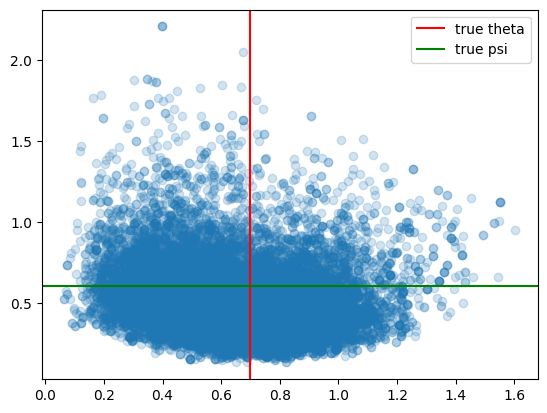

In [26]:
import matplotlib.pyplot as plt
def MCMC(X, n_iter=20000, proposal_sd=0.15):
    samples = np.zeros((n_iter, 2))

    # we start at sample mean and sample variance
    theta_current = np.mean(X)
    psi_current = np.var(X, ddof=1)
    xi_current = np.log(theta_current)
    gamma_current = np.log(psi_current)

    logpost_current = log_posterior(theta_current, psi_current, X)

    accepted = 0
    for t in range(n_iter):
        xi_prop = xi_current + np.random.normal(0, proposal_sd)
        gamma_prop = gamma_current + np.random.normal(0, proposal_sd)
        theta_prop = np.exp(xi_prop)
        psi_prop = np.exp(gamma_prop)

        logpost_prop = log_posterior(theta_prop, psi_prop, X)

        log_alpha = logpost_prop - logpost_current
        if np.log(np.random.rand()) < log_alpha:
            xi_current = xi_prop
            gamma_current = gamma_prop
            theta_current = theta_prop
            psi_current = psi_prop
            logpost_current = logpost_prop
            accepted += 1

        samples[t] = [theta_current, psi_current]

    print("Acceptance rate:", accepted/n_iter)
    return samples

n=10
X = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=n)
samples = MCMC(X, n_iter=20000, proposal_sd=0.15)

burn_in = 1000
post_samples = samples[burn_in:]

print("Posterior mean theta:", np.mean(post_samples[:, 0]))
print("Posterior mean psi:", np.mean(post_samples[:, 1]))

plt.scatter(post_samples[:, 0], post_samples[:, 1], alpha=0.2)
plt.axvline(theta_true,color="red",label="true theta")
plt.axhline(psi_true,color="green",label="true psi")
plt.legend()
plt.show()

Acceptance rate: 0.51
Posterior mean theta: 0.5972202710919453
Posterior mean psi: 0.5992350595844624


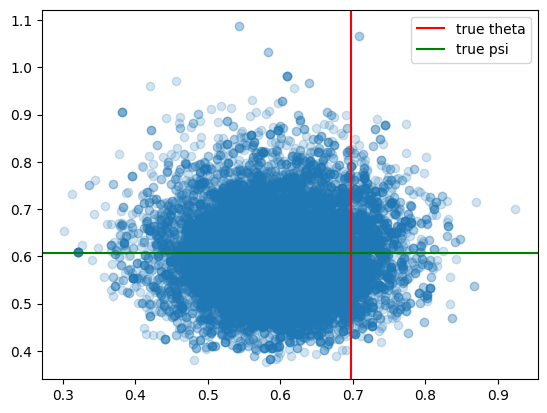

In [27]:
# (e) repeat with n=100 and n=1000
X = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=100)
samples = MCMC(X, n_iter=20000, proposal_sd=0.15)

burn_in = 1000
post_samples = samples[burn_in:]

print("Posterior mean theta:", np.mean(post_samples[:, 0]))
print("Posterior mean psi:", np.mean(post_samples[:, 1]))

plt.scatter(post_samples[:, 0], post_samples[:, 1], alpha=0.2)
plt.axvline(theta_true,color="red",label="true theta")
plt.axhline(psi_true,color="green",label="true psi")
plt.legend()
plt.show()

Acceptance rate: 0.11155
Posterior mean theta: 0.7438709083856742
Posterior mean psi: 0.6330957133923684


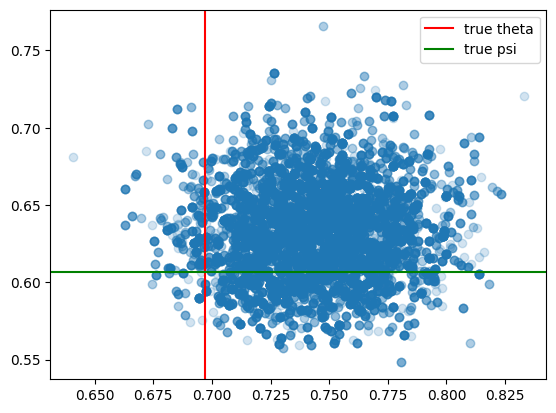

In [28]:
X = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=1000)
samples = MCMC(X, n_iter=20000, proposal_sd=0.15)

burn_in = 1000
post_samples = samples[burn_in:]

print("Posterior mean theta:", np.mean(post_samples[:, 0]))
print("Posterior mean psi:", np.mean(post_samples[:, 1]))

plt.scatter(post_samples[:, 0], post_samples[:, 1], alpha=0.2)
plt.axvline(theta_true,color="red",label="true theta")
plt.axhline(psi_true,color="green",label="true psi")
plt.legend()
plt.show()

In [ ]:
# (f)